In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 22,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',
    'figure.dpi': 100,
    'savefig.bbox': 'tight',
    
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

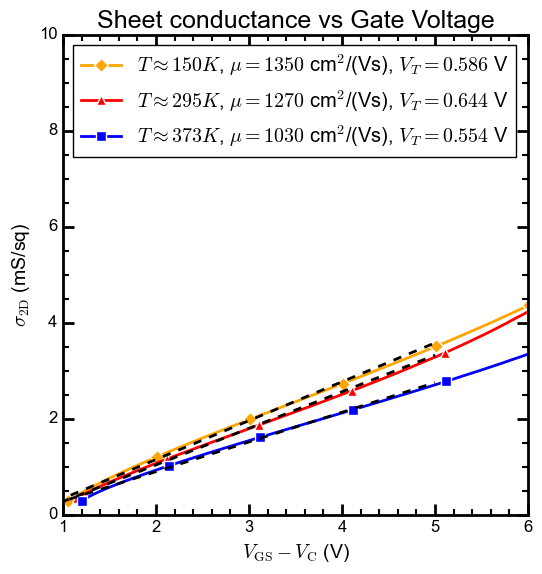

In [53]:
data1 = np.loadtxt("./Mobility/20262004004.dat")
data2 = np.loadtxt("./Data-20262805-gvdP/20262805005.dat")
data3 = np.loadtxt("./Data-20262805-gvdP/20262805014.dat")

datasets_gvdP = [
    ("150 K", data3, 'orange', 'D', 10, 1350, 0.586),
    ("295 K", data1, 'red', '^', 80, 1270, 0.644),
    ("373 K", data2, 'blue', 's', 10, 1030, 0.554),
]
plt.figure(figsize=(6, 6))

for label, data, color, marker, markevery, mu_cm2_vs, V_T in datasets_gvdP:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5*(data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    plt.plot(
        V_GS - V_C,
        sigma*1e3,
        lw=2,
        label=rf"$T \approx {label}$, $\mu={mu_cm2_vs}$ cm$^2$/(Vs), $V_T={V_T:.3f}$ V",
        color=color,
        marker=marker,
        linestyle='-',
        markevery=markevery,
        markeredgecolor="white", markeredgewidth=1, markersize=7,
    )

C = 3e-12  # 3pF
W = 50e-6  # 50um
L = 10e-6  # 10um
Ci = C / (W * L)  # F/m^2

linear_lines = [
    ("150 K", 1350, 0.586),
    ("373 K", 1030, 0.554),
    ("295 K", 1270, 0.644),
]

for temp_label, mu_cm2_vs, V_T in linear_lines:
    x_line = np.linspace(V_T, 5, 200)
    sigma_line = Ci * (mu_cm2_vs / 1e4) * (x_line - V_T) * 1e3
    plt.plot(x_line, sigma_line, 'k--', lw=2)

plt.xlabel(r"$V_\text{GS} - V_\text{C}$ (V)", fontsize=14)
plt.ylabel(r"$\sigma_\text{2D}$ (mS/sq)", fontsize=14)
plt.xlim(1, 6)
plt.ylim(0, 10)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage", fontsize=18)
plt.savefig("vdP_sigma_ALD1106.eps", format='eps', bbox_inches='tight')
plt.show()


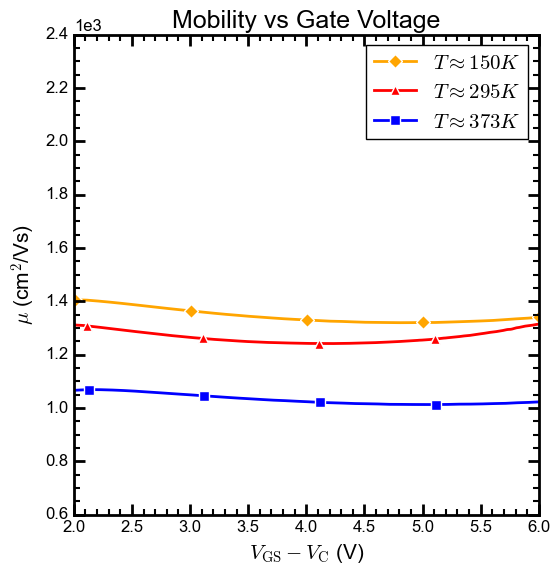

In [54]:
plt.figure(figsize=(6, 6))
for label, data, color, marker, markevery, mu_cm2_vs, V_T in datasets_gvdP:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5*(data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    plt.plot(
        V_GS - V_C,
        sigma/Ci/(V_GS - V_C - V_T) * 1e4,
        lw=2,
        label=rf"$T \approx {label}$",
        color=color,
        marker=marker,
        linestyle='-',
        markevery=markevery,
        markeredgecolor="white", markeredgewidth=1, markersize=7,
    )
plt.xlabel(r"$V_\text{GS} - V_\text{C}$ (V)", fontsize=15)
plt.ylabel(r"$\mu$ (cm$^2$/Vs)", fontsize=15)
plt.xlim(2, 6)
plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3), useMathText=False)
plt.legend(frameon=True, numpoints=1, fontsize=15)
plt.title("Mobility vs Gate Voltage", fontsize=18)
plt.savefig("vdP_mu_ALD1106.eps", format='eps')
plt.show()